# CTTS — CNN + Transformer for Kalshi Jump Detection

Builds on the Milestone 3 `JumpCNN` baseline. The CNN is reused as a **tokenizer**: each window of trades is convolved into a sequence of local embeddings, which a Transformer encoder then attends over to capture long-range structure. **Binary** jump label — same as the baseline: `y = 1` iff `jump3_{H}m != 0` (i.e., the trade sits at the endpoint of a large up- *or* down-move at horizon H), else `0`.

**Architecture:**

```
trade window (B, F, L)
      │
      ▼  3-block 1D CNN (same as JumpCNN, no final pooling)
tokens (B, L', d_model)
      │   + positional embedding
      ▼  Transformer encoder (depth 4, 4 heads)
      │
      ▼  CLS token / mean-pool
MLP head → single logit → sigmoid
```

**Trained per horizon** H ∈ {5, 15, 30, 60} minutes — same convention as the baseline.

Pipeline:
1. Load `all_trades_features.parquet`
2. Per-ticker, per-horizon causal windowing (length L = 64 trades)
3. Standard min-max scaling on `yes_price` per window (CTTS preprocessing); other features kept on engineered scale
4. Temporal train / val / test split (re-using preprocessing's `split` column, val carved from end-of-train)
5. Train CTTS with `BCEWithLogitsLoss` + `pos_weight` for class imbalance — matches the baseline
6. Threshold search on val: lowest cutoff achieving ≥60% precision (`MIN_PRECISION_TARGET = 0.60`, same as the baseline)
7. Evaluate on test: AUC-PR, AUC-ROC, accuracy, balanced accuracy, F1, MCC, confusion matrix

In [1]:
import os
import math
import json
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_recall_fscore_support, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    google.colab.drive.mount('/content/drive')
except ImportError:
    pass

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}', f'GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else '')

DATA_ROOT     = '/content/drive/MyDrive/109B/Project/Data'
FEATURES_PATH = os.path.join(DATA_ROOT, 'All Trades Features.parquet')
CKPT_DIR      = os.path.join(DATA_ROOT, 'checkpoints_ctts')
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

Mounted at /content/drive
Device: cuda GPU: NVIDIA A100-SXM4-80GB


In [2]:
@dataclass
class Config:
    # Data
    horizons:        tuple = (5, 15, 30, 60)
    lookback:        int   = 64
    min_trades_tkr:  int   = 50
    val_frac_of_train: float = 0.15

    # CNN tokenizer (mirrors baseline JumpCNN)
    cnn_ch1:    int = 64
    cnn_ch2:    int = 128
    cnn_ch3:    int = 256
    cnn_kernel: int = 3
    cnn_dropout: float = 0.2

    # Transformer
    tf_depth:   int   = 4
    tf_heads:   int   = 4
    tf_dim_ff:  int   = 512
    tf_dropout: float = 0.3
    pool:       str   = 'cls'

    # Optimization
    batch_size:    int   = 512
    lr:            float = 3e-4
    weight_decay:  float = 1e-4
    max_epochs:    int   = 25
    patience:      int   = 4
    grad_clip:     float = 1.0
    num_workers:   int   = 4

    # Subsampling caps — 2M train, val/test scaled proportionally
    max_train_windows: int = 800_000
    max_val_windows:   int = 160_000
    max_test_windows:  int = 160_000

CFG = Config()
print(json.dumps(asdict(CFG), indent=2))

{
  "horizons": [
    5,
    15,
    30,
    60
  ],
  "lookback": 64,
  "min_trades_tkr": 50,
  "val_frac_of_train": 0.15,
  "cnn_ch1": 64,
  "cnn_ch2": 128,
  "cnn_ch3": 256,
  "cnn_kernel": 3,
  "cnn_dropout": 0.2,
  "tf_depth": 4,
  "tf_heads": 4,
  "tf_dim_ff": 512,
  "tf_dropout": 0.3,
  "pool": "cls",
  "batch_size": 512,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "max_epochs": 25,
  "patience": 4,
  "grad_clip": 1.0,
  "num_workers": 4,
  "max_train_windows": 800000,
  "max_val_windows": 160000,
  "max_test_windows": 160000
}


In [3]:
import pyarrow.parquet as pq
import gc

# Define the columns we actually need
META_COLS = ['ticker', 'created_time', 'split']
LABEL_COLS = [f'jump3_{h}m' for h in CFG.horizons]
EMB_COLS = [f'ticker_emb_{i}' for i in range(8)]

FEATURE_COLS = (
    ['yes_price', 'log_volume', 'log_time_delta',
     'ret_last_5', 'ret_last_10', 'ret_last_20',
     'position_in_range', 'dist_from_50',
     'relative_volume', 'tick', 'run_length',
     'volume_since_price_change',
     'trades_last_60s', 'trades_last_300s',
     'hour_sin', 'hour_cos']
    + [f'backward_ret_{h}m'      for h in CFG.horizons]
    + [f'backward_abs_ret_{h}m'  for h in CFG.horizons]
    + [f'recent_up_jumps_{h}m'   for h in CFG.horizons]
    + [f'recent_down_jumps_{h}m' for h in CFG.horizons]
    + EMB_COLS
)
PRICE_IDX = FEATURE_COLS.index('yes_price')
F_DIM     = len(FEATURE_COLS)

NEEDED = META_COLS + FEATURE_COLS + LABEL_COLS

# ---- Pass 1: count rows so we can pre-allocate ----------------
pf = pq.ParquetFile(FEATURES_PATH)
N = pf.metadata.num_rows
print(f'Total rows in parquet: {N:,}')

# ---- Pre-allocate output arrays --------------------------------
FEATURE_MATRIX = np.empty((N, F_DIM),  dtype=np.float32)
LABELS         = np.empty((N, len(LABEL_COLS)), dtype=np.float32)
times          = np.empty(N, dtype='datetime64[ns]')
tickers        = np.empty(N, dtype=object)         # filled then converted to category
splits         = np.empty(N, dtype=object)

# ---- Pass 2: stream batches into the pre-allocated arrays -----
print('Streaming parquet into pre-allocated arrays...')
offset = 0
for batch in tqdm(pf.iter_batches(batch_size=2_000_000, columns=NEEDED)):
    b = batch.to_pandas()
    n = len(b)
    sl = slice(offset, offset + n)

    # features
    for j, c in enumerate(FEATURE_COLS):
        FEATURE_MATRIX[sl, j] = b[c].to_numpy(dtype=np.float32, copy=False)
    # labels
    for j, c in enumerate(LABEL_COLS):
        LABELS[sl, j] = b[c].to_numpy(dtype=np.float32, copy=False)
    # metadata
    times[sl]   = pd.to_datetime(b['created_time'], utc=True).values.astype('datetime64[ns]')
    tickers[sl] = b['ticker'].astype(str).values
    splits[sl]  = b['split'].astype(str).values

    offset += n
    del b; gc.collect()

assert offset == N, f'Expected {N} rows, got {offset}'

# ---- Clean NaN/inf in features --------------------------------
print('Cleaning NaN/inf in feature matrix...')
np.nan_to_num(FEATURE_MATRIX, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

# ---- Build a *small* metadata DataFrame -----------------------
df = pd.DataFrame({
    'ticker':       pd.Categorical(tickers),
    'created_time': times,
    'split':        pd.Categorical(splits),
})
for j, c in enumerate(LABEL_COLS):
    df[c] = LABELS[:, j]

del tickers, splits, times, LABELS
gc.collect()

# ---- Sort and rebuild --------------------------------------
print('Sorting by ticker, time...')
order = np.lexsort((df['created_time'].values.astype('datetime64[ns]').view('int64'),
                    df['ticker'].cat.codes.values))
FEATURE_MATRIX = FEATURE_MATRIX[order]
df = df.iloc[order].reset_index(drop=True)

print(f'Trades         : {len(df):,}')
print(f'Feature dim F  : {F_DIM}')
print(f'Tickers        : {df["ticker"].nunique():,}')
print(f'Date range     : {df["created_time"].min()}  ->  {df["created_time"].max()}')
print(f'Split counts   :\n{df["split"].value_counts()}')
print(f'FEATURE_MATRIX : {FEATURE_MATRIX.shape}   {FEATURE_MATRIX.nbytes / 1e9:.2f} GB')
print(f'df             : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Total rows in parquet: 63,801,798
Streaming parquet into pre-allocated arrays...


0it [00:00, ?it/s]

Cleaning NaN/inf in feature matrix...
Sorting by ticker, time...
Trades         : 63,801,798
Feature dim F  : 40
Tickers        : 517,520
Date range     : 2025-01-01 00:00:09.673219  ->  2025-11-25 22:00:15.194245
Split counts   :
split
train    51041438
test     12760360
Name: count, dtype: int64
FEATURE_MATRIX : (63801798, 40)   10.21 GB
df             : 1.91 GB


In [4]:
# Drop sparse tickers
tkr_counts = df.groupby('ticker', sort=False, observed=True).size()
keep_tickers = set(tkr_counts[tkr_counts >= CFG.min_trades_tkr].index)
keep_mask = df['ticker'].isin(keep_tickers).values

df = df[keep_mask].reset_index(drop=True)
FEATURE_MATRIX = FEATURE_MATRIX[keep_mask]   # keep them aligned
print(f'After filter: {len(df):,} trades, {df["ticker"].nunique():,} tickers, '
      f'FEATURE_MATRIX {FEATURE_MATRIX.shape}')

df = df.sort_values(['ticker', 'created_time'], kind='stable')
order = df.index.values
df = df.reset_index(drop=True)
FEATURE_MATRIX = FEATURE_MATRIX[order]   # re-order to match the sorted df

ticker_codes = df['ticker'].cat.codes.values
change_pts   = np.where(np.diff(ticker_codes) != 0)[0] + 1
TICKER_STARTS = np.concatenate([[0], change_pts])
TICKER_ENDS   = np.concatenate([change_pts, [len(df)]])

After filter: 60,938,701 trades, 90,924 tickers, FEATURE_MATRIX (60938701, 40)


In [5]:
# Windowing
def build_window_index(df, ticker_starts, ticker_ends, lookback, horizon):
    """Return (end_indices, labels, splits) for valid windows of length `lookback`.

    Each window covers rows [end - lookback + 1, end] inclusive, all from the same ticker.
    Labels for which jump3_{horizon}m is NaN are filtered out (no future observation).
    """
    label_col   = f'jump3_{horizon}m'
    labels_all  = df[label_col].values.astype(np.float32)
    splits_all  = df['split'].values

    end_indices = []
    for s, e in zip(ticker_starts, ticker_ends):
        if e - s < lookback:
            continue
        end_indices.append(np.arange(s + lookback - 1, e, dtype=np.int64))
    end_indices = np.concatenate(end_indices)

    labels = labels_all[end_indices]
    splits = splits_all[end_indices]

    valid = ~np.isnan(labels)
    return end_indices[valid], labels[valid], splits[valid]


# Inspect for the primary horizon
ends_15, lbls_15, splits_15 = build_window_index(df, TICKER_STARTS, TICKER_ENDS, CFG.lookback, 15)
print(f'15m horizon — total valid windows: {len(ends_15):,}')
for s in ['train', 'test']:
    mask = splits_15 == s
    print(f'    {s:5s} {mask.sum():>10,}   class dist: '
          f'{pd.Series(lbls_15[mask]).value_counts(normalize=True).sort_index().to_dict()}')

15m horizon — total valid windows: 55,285,407
    train 43,871,678   class dist: {-1.0: 0.0936973507145088, 0.0: 0.8123102790825553, 1.0: 0.09399237020293594}
    test  11,413,729   class dist: {-1.0: 0.10652416927018331, 0.0: 0.7883551466834371, 1.0: 0.10512068404637959}


**CTTS**

In [6]:

class CNNTokenizer(nn.Module):
    """Reuses the JumpCNN body. Produces (B, d_model, L') instead of pooling."""
    def __init__(self, in_ch, ch1=64, ch2=128, ch3=256, k=3, dropout=0.2):
        super().__init__()
        p = k // 2
        self.block1 = nn.Sequential(
            nn.Conv1d(in_ch, ch1, kernel_size=k, padding=p),
            nn.BatchNorm1d(ch1), nn.ReLU(inplace=True),
            nn.Conv1d(ch1, ch1, kernel_size=k, padding=p),
            nn.BatchNorm1d(ch1), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(ch1, ch2, kernel_size=k, padding=p),
            nn.BatchNorm1d(ch2), nn.ReLU(inplace=True),
            nn.Conv1d(ch2, ch2, kernel_size=k, padding=p),
            nn.BatchNorm1d(ch2), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(ch2, ch3, kernel_size=k, padding=p),
            nn.BatchNorm1d(ch3), nn.ReLU(inplace=True),
            # NO AdaptiveAvgPool1d — keep spatial dimension as token sequence.
        )
        self.out_dim = ch3

    def forward(self, x):                # x: (B, F, L)
        x = self.block1(x)               # (B, ch1, L/2)
        x = self.block2(x)               # (B, ch2, L/4)
        x = self.block3(x)               # (B, ch3, L/4)
        return x


class SinusoidalPosEnc(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):                              # x: (B, T, d_model)
        return x + self.pe[:, : x.size(1)]


class CTTS(nn.Module):
    """CNN tokenizer + Transformer encoder + MLP head.
    Predicts a 3-way distribution over {down-jump, no-jump, up-jump}.
    """
    def __init__(self, in_features, num_classes=3,
                 ch1=64, ch2=128, ch3=256, cnn_kernel=3, cnn_dropout=0.2,
                 tf_depth=4, tf_heads=4, tf_dim_ff=512, tf_dropout=0.3,
                 pool='cls'):
        super().__init__()
        assert pool in ('cls', 'mean')
        self.pool = pool

        self.tokenizer = CNNTokenizer(in_features, ch1, ch2, ch3, cnn_kernel, cnn_dropout)
        d = self.tokenizer.out_dim

        self.cls = nn.Parameter(torch.zeros(1, 1, d))
        nn.init.trunc_normal_(self.cls, std=0.02)

        self.pos = SinusoidalPosEnc(d, max_len=512)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=tf_heads, dim_feedforward=tf_dim_ff,
            dropout=tf_dropout, activation='gelu',
            batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=tf_depth)
        self.norm    = nn.LayerNorm(d)

        self.head = nn.Sequential(
            nn.Linear(d, d // 2), nn.GELU(), nn.Dropout(tf_dropout),
            nn.Linear(d // 2, num_classes),
        )

    def forward(self, x):                                 # x: (B, F, L)
        tokens = self.tokenizer(x).transpose(1, 2)        # (B, T, d)

        if self.pool == 'cls':
            cls = self.cls.expand(tokens.size(0), -1, -1)
            tokens = torch.cat([cls, tokens], dim=1)

        tokens = self.pos(tokens)
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)

        rep = tokens[:, 0] if self.pool == 'cls' else tokens.mean(dim=1)
        return self.head(rep)


# Sanity check
_m = CTTS(in_features=F_DIM)
_x = torch.randn(2, F_DIM, CFG.lookback)
_y = _m(_x)
print(f'CTTS output shape : {_y.shape}    (expected: (2, 3))')
print(f'Trainable params  : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')

CTTS output shape : torch.Size([2, 3])    (expected: (2, 3))
Trainable params  : 2,336,387


In [7]:
class TradeWindowDataset(Dataset):
    """Causal trade windows from the preprocessed feature matrix.

    Args:
        feature_matrix : (N, F) float32 — global feature matrix.
        end_indices    : (M,) int64    — last-row index of each window.
        labels         : (M,) float32  — 3-class label in {-1, 0, +1}.
        lookback       : int           — window length L.
        price_idx      : int           — column index of yes_price.
    """
    def __init__(self, feature_matrix, end_indices, labels, lookback, price_idx):
        self.X         = feature_matrix
        self.ends      = end_indices.astype(np.int64)
        self.labels    = labels.astype(np.int64) + 1   # {-1,0,1} -> {0,1,2} for CE
        self.L         = lookback
        self.price_idx = price_idx

    def __len__(self):
        return len(self.ends)

    def __getitem__(self, idx):
        e = self.ends[idx]
        s = e - self.L + 1
        window = self.X[s:e + 1].copy()                      # (L, F)

        # CTTS-style min-max on yes_price within window
        p = window[:, self.price_idx]
        p_min, p_max = p.min(), p.max()
        denom = max(p_max - p_min, 1e-6)
        window[:, self.price_idx] = (p - p_min) / denom

        x = torch.from_numpy(window.T)                       # (F, L)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

Training Loop

In [8]:
def make_splits(end_indices, labels, splits, val_frac):
    """Carve a temporal val slice off the end of train (sorted by created_time)."""
    train_mask = splits == 'train'
    test_mask  = splits == 'test'
    train_ends, train_lbls = end_indices[train_mask], labels[train_mask]
    test_ends,  test_lbls  = end_indices[test_mask],  labels[test_mask]

    times = df['created_time'].values[train_ends]
    order = np.argsort(times)
    train_ends = train_ends[order]; train_lbls = train_lbls[order]
    cut = int(len(train_ends) * (1 - val_frac))
    return ((train_ends[:cut], train_lbls[:cut]),
            (train_ends[cut:], train_lbls[cut:]),
            (test_ends,        test_lbls))


def subsample(ends, labels, n_max, rng):
    """Stratified subsample preserving class proportions."""
    if n_max is None or len(ends) <= n_max:
        return ends, labels
    classes, counts = np.unique(labels, return_counts=True)
    keep = []
    for c, cnt in zip(classes, counts):
        idx = np.where(labels == c)[0]
        n_c = int(round(n_max * cnt / counts.sum()))
        keep.append(rng.choice(idx, size=min(n_c, len(idx)), replace=False))
    keep = np.concatenate(keep)
    rng.shuffle(keep)
    return ends[keep], labels[keep]


def class_weights(labels_int, num_classes=3, device='cpu', power=0.5):
    counts = np.bincount(labels_int + 1, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1)
    w = (counts.sum() / (num_classes * counts)) ** power
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        all_logits.append(logits.float().cpu())
        all_y.append(y)
    logits = torch.cat(all_logits).numpy()
    y      = torch.cat(all_y).numpy()
    probs  = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred   = probs.argmax(axis=1)
    return {
        'logits': logits, 'probs': probs, 'pred': pred, 'true': y,
        'acc':      accuracy_score(y, pred),
        'bal_acc':  balanced_accuracy_score(y, pred),
        'macro_f1': f1_score(y, pred, average='macro'),
    }


def train_one_horizon(horizon, cfg, df, ticker_starts, ticker_ends, feature_matrix, device):
    print(f'\n==================================================')
    print(f'  CTTS  ·  horizon = {horizon}m')
    print(f'==================================================')
    rng = np.random.default_rng(SEED + horizon)

    ends, labels, splits = build_window_index(df, ticker_starts, ticker_ends, cfg.lookback, horizon)
    (tr_ends, tr_lbls), (va_ends, va_lbls), (te_ends, te_lbls) = make_splits(
        ends, labels, splits, cfg.val_frac_of_train)

    tr_lbls_int = tr_lbls.astype(np.int64)
    va_lbls_int = va_lbls.astype(np.int64)
    te_lbls_int = te_lbls.astype(np.int64)
    tr_ends, tr_lbls_int = subsample(tr_ends, tr_lbls_int, cfg.max_train_windows, rng)
    va_ends, va_lbls_int = subsample(va_ends, va_lbls_int, cfg.max_val_windows,   rng)
    te_ends, te_lbls_int = subsample(te_ends, te_lbls_int, cfg.max_test_windows,  rng)

    print(f'  train windows : {len(tr_ends):>9,}   class dist {pd.Series(tr_lbls_int).value_counts(normalize=True).sort_index().to_dict()}')
    print(f'  val windows   : {len(va_ends):>9,}   class dist {pd.Series(va_lbls_int).value_counts(normalize=True).sort_index().to_dict()}')
    print(f'  test windows  : {len(te_ends):>9,}   class dist {pd.Series(te_lbls_int).value_counts(normalize=True).sort_index().to_dict()}')

    ds_tr = TradeWindowDataset(feature_matrix, tr_ends, tr_lbls_int.astype(np.float32), cfg.lookback, PRICE_IDX)
    ds_va = TradeWindowDataset(feature_matrix, va_ends, va_lbls_int.astype(np.float32), cfg.lookback, PRICE_IDX)
    ds_te = TradeWindowDataset(feature_matrix, te_ends, te_lbls_int.astype(np.float32), cfg.lookback, PRICE_IDX)
    pin = device == 'cuda'
    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True,
                       num_workers=cfg.num_workers, pin_memory=pin, drop_last=True)
    dl_va = DataLoader(ds_va, batch_size=cfg.batch_size, shuffle=False,
                       num_workers=cfg.num_workers, pin_memory=pin)
    dl_te = DataLoader(ds_te, batch_size=cfg.batch_size, shuffle=False,
                       num_workers=cfg.num_workers, pin_memory=pin)

    model = CTTS(in_features=F_DIM,
                 ch1=cfg.cnn_ch1, ch2=cfg.cnn_ch2, ch3=cfg.cnn_ch3,
                 cnn_kernel=cfg.cnn_kernel, cnn_dropout=cfg.cnn_dropout,
                 tf_depth=cfg.tf_depth, tf_heads=cfg.tf_heads,
                 tf_dim_ff=cfg.tf_dim_ff, tf_dropout=cfg.tf_dropout,
                 pool=cfg.pool).to(device)

    weights = class_weights(tr_lbls_int, num_classes=3, device=device)
    print(f'  class weights : {weights.cpu().numpy().round(3).tolist()}')
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.max_epochs)
    use_amp = False
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    history = []
    best_f1, best_epoch = -1.0, -1
    ckpt_path = os.path.join(CKPT_DIR, f'ctts_{horizon}m.pt')

    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        running, n = 0.0, 0
        pbar = tqdm(dl_tr, desc=f'  ep {epoch:02d}', leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer); scaler.update()
            running += loss.item() * x.size(0); n += x.size(0)
            pbar.set_postfix(loss=f'{running / n:.4f}')
        scheduler.step()
        train_loss = running / max(n, 1)

        val = evaluate(model, dl_va, device)
        history.append({'epoch': epoch, 'train_loss': train_loss,
                        'val_acc': val['acc'], 'val_bal_acc': val['bal_acc'],
                        'val_macro_f1': val['macro_f1']})
        print(f'  ep {epoch:02d}  train_loss {train_loss:.4f}  '
              f'val_acc {val["acc"]:.4f}  bal_acc {val["bal_acc"]:.4f}  '
              f'macro_f1 {val["macro_f1"]:.4f}')

        if val['macro_f1'] > best_f1:
            best_f1, best_epoch = val['macro_f1'], epoch
            torch.save({'state_dict': model.state_dict(), 'config': asdict(cfg),
                        'horizon': horizon, 'epoch': epoch,
                        'val_macro_f1': best_f1}, ckpt_path)
        elif epoch - best_epoch >= cfg.patience:
            print(f'  early stop @ ep {epoch}  (best ep {best_epoch}, macro_f1 {best_f1:.4f})')
            break

    print(f'  loading best ep {best_epoch} (val_macro_f1 {best_f1:.4f})')
    model.load_state_dict(torch.load(ckpt_path, map_location=device)['state_dict'])
    test = evaluate(model, dl_te, device)
    print(f'  TEST  acc {test["acc"]:.4f}   bal_acc {test["bal_acc"]:.4f}   macro_f1 {test["macro_f1"]:.4f}')
    return {'history': history, 'val': evaluate(model, dl_va, device),
            'test': test, 'ckpt_path': ckpt_path}

In [9]:
results = {}
for H in CFG.horizons:
    results[H] = train_one_horizon(H, CFG, df, TICKER_STARTS, TICKER_ENDS, FEATURE_MATRIX, DEVICE)


  CTTS  ·  horizon = 5m
  train windows :   800,000   class dist {-1: 0.08428, 0: 0.83119375, 1: 0.08452625}
  val windows   :   159,999   class dist {-1: 0.08421302633141457, 0: 0.8298301864386652, 1: 0.08595678722992019}
  test windows  :   160,000   class dist {-1: 0.0962875, 0: 0.80765, 1: 0.0960625}
  class weights : [1.2949999570846558, 0.41200000047683716, 1.2929999828338623]


  ep 01:   0%|          | 0/1562 [00:00<?, ?it/s]

  ep 01  train_loss 0.7422  val_acc 0.8020  bal_acc 0.4215  macro_f1 0.4330


  ep 02:   0%|          | 0/1562 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
     Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0> 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
 Traceback (most recent call last):
Exception ignored in: ^    ^    self._shutdown_workers()^
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^<function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0>if w.is_alive():
^

Traceback (most recent cal

...

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0>



Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
                self._shutdown_workers()self._shutdown_workers()self._shutdown_workers()

  ep 12  train_loss 0.5632  val_acc 0.7461  bal_acc 0.5168  macro_f1 0.4982


  ep 13:   0%|          | 0/1562 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dd6c05a27a0>



Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
                self._shutdown_workers()self._shutdown_workers()self._shutdown_workers()

  ep 13  train_loss 0.5555  val_acc 0.7276  bal_acc 0.5190  macro_f1 0.4973
  early stop @ ep 13  (best ep 9, macro_f1 0.5070)
  loading best ep 9 (val_macro_f1 0.5070)
  TEST  acc 0.7395   bal_acc 0.5366   macro_f1 0.5128


In [9]:
# ============================================================
# Inference for MoE handoff
# Run all 4 trained models on EVERY trade in the dataset and
# emit a single parquet with one row per trade + 12 probability cols.
# ============================================================

import gc
from tqdm.auto import tqdm

# Will use the same model class, dataset utilities, FEATURE_MATRIX,
# df, TICKER_STARTS, TICKER_ENDS, results, CFG already in memory.

INFER_BATCH = 2048   # bigger than training; no grads, less GPU memory

def build_all_window_ends(ticker_starts, ticker_ends, lookback):
    """One window per trade where a full lookback is available. No label filtering."""
    end_indices = []
    for s, e in zip(ticker_starts, ticker_ends):
        if e - s < lookback:
            continue
        end_indices.append(np.arange(s + lookback - 1, e, dtype=np.int64))
    return np.concatenate(end_indices) if end_indices else np.array([], dtype=np.int64)


class InferenceWindowDataset(Dataset):
    """Same windowing + per-window min-max as training, but no labels."""
    def __init__(self, feature_matrix, end_indices, lookback, price_idx):
        self.X         = feature_matrix
        self.ends      = end_indices.astype(np.int64)
        self.L         = lookback
        self.price_idx = price_idx

    def __len__(self):
        return len(self.ends)

    def __getitem__(self, idx):
        e = self.ends[idx]
        s = e - self.L + 1
        window = self.X[s:e + 1].copy()
        p = window[:, self.price_idx]
        p_min, p_max = p.min(), p.max()
        denom = max(p_max - p_min, 1e-6)
        window[:, self.price_idx] = (p - p_min) / denom
        return torch.from_numpy(window.T), e   # return the trade index too


# Build window-end indices once (same for all 4 horizons since lookback is fixed)
all_ends = build_all_window_ends(TICKER_STARTS, TICKER_ENDS, CFG.lookback)
N_total = len(df)
N_windows = len(all_ends)
print(f'Total trades            : {N_total:,}')
print(f'Trades with full window : {N_windows:,}  ({100*N_windows/N_total:.1f}%)')
print(f'Trades without window   : {N_total - N_windows:,}  (will be NaN)')

# Allocate output arrays — 3 classes × 4 horizons = 12 columns of probabilities
# Order: [down, no_jump, up] for each horizon, NaN by default
proba_columns = {}
for H in CFG.horizons:
    for cls in ('down', 'no_jump', 'up'):
        proba_columns[f'probability_{cls}_{H}m_ctts'] = np.full(N_total, np.nan, dtype=np.float32)


# Run inference one horizon at a time (keeps GPU memory low)
ds = InferenceWindowDataset(FEATURE_MATRIX, all_ends, CFG.lookback, PRICE_IDX)
dl = DataLoader(ds, batch_size=INFER_BATCH, shuffle=False,
                num_workers=CFG.num_workers, pin_memory=(DEVICE == 'cuda'))

for H in CFG.horizons:
    print(f'\nHorizon {H}m — loading checkpoint and running inference...')
    # Rebuild the model and load weights
    model = CTTS(in_features=F_DIM,
                 ch1=CFG.cnn_ch1, ch2=CFG.cnn_ch2, ch3=CFG.cnn_ch3,
                 cnn_kernel=CFG.cnn_kernel, cnn_dropout=CFG.cnn_dropout,
                 tf_depth=CFG.tf_depth, tf_heads=CFG.tf_heads,
                 tf_dim_ff=CFG.tf_dim_ff, tf_dropout=CFG.tf_dropout,
                 pool=CFG.pool).to(DEVICE)
    ckpt_path = os.path.join(CKPT_DIR, f'ctts_{H}m.pt')
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['state_dict'])
    model.eval()

    # Allocate per-horizon output buffer (only for windowed trades)
    probs_for_H = np.empty((N_windows, 3), dtype=np.float32)
    write_pos = 0

    with torch.no_grad():
        for x, _idx in tqdm(dl, desc=f'  {H}m inference'):
            x = x.to(DEVICE, non_blocking=True)
            logits = model(x)                                # (B, 3) — [down, flat, up]
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            bsz = probs.shape[0]
            probs_for_H[write_pos:write_pos + bsz] = probs
            write_pos += bsz

    assert write_pos == N_windows, f'Expected {N_windows} predictions, got {write_pos}'

    # Scatter probabilities back to the full-length arrays.
    # Model output order is [down=0, flat=1, up=2] (labels were shifted -1/0/+1 -> 0/1/2).
    proba_columns[f'probability_down_{H}m_ctts'][all_ends]    = probs_for_H[:, 0]
    proba_columns[f'probability_no_jump_{H}m_ctts'][all_ends] = probs_for_H[:, 1]
    proba_columns[f'probability_up_{H}m_ctts'][all_ends]      = probs_for_H[:, 2]

    # Cleanup
    del model, probs_for_H
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print('\nAll horizons done. Assembling output dataframe...')

# Build the output dataframe — ticker, created_time, then 12 probability cols
out = pd.DataFrame({
    'ticker':       df['ticker'].astype(str).values,     # plain strings, easier to consume
    'created_time': df['created_time'].values,
})
for col_name, col_values in proba_columns.items():
    out[col_name] = col_values

# Make sure column order matches what Andres asked for:
# ticker, created_time, then per-horizon (no_jump, up, down)
final_cols = ['ticker', 'created_time']
for H in CFG.horizons:
    final_cols += [f'probability_no_jump_{H}m_ctts',
                   f'probability_up_{H}m_ctts',
                   f'probability_down_{H}m_ctts']
out = out[final_cols]

print(f'Output shape: {out.shape}')
print(f'Columns: {list(out.columns)}')
print(f'\nSample (first 3 rows with a valid window):')
first_valid = all_ends[0]
print(out.iloc[first_valid:first_valid + 3])

print(f'\nMissing-probability count (no full window): '
      f'{out.iloc[:, 2:].isna().any(axis=1).sum():,}')

# Save
out_path = os.path.join(DATA_ROOT, 'ctts_predictions_for_moe.parquet')
out.to_parquet(out_path, index=False, compression='zstd')
print(f'\nSaved to: {out_path}')
print(f'File size: {os.path.getsize(out_path) / 1e6:.1f} MB')

Total trades            : 60,938,701
Trades with full window : 55,285,407  (90.7%)
Trades without window   : 5,653,294  (will be NaN)

Horizon 5m — loading checkpoint and running inference...


  5m inference:   0%|          | 0/26995 [00:00<?, ?it/s]


Horizon 15m — loading checkpoint and running inference...


  15m inference:   0%|          | 0/26995 [00:00<?, ?it/s]


Horizon 30m — loading checkpoint and running inference...


  30m inference:   0%|          | 0/26995 [00:00<?, ?it/s]


Horizon 60m — loading checkpoint and running inference...


  60m inference:   0%|          | 0/26995 [00:00<?, ?it/s]


All horizons done. Assembling output dataframe...
Output shape: (60938701, 14)
Columns: ['ticker', 'created_time', 'probability_no_jump_5m_ctts', 'probability_up_5m_ctts', 'probability_down_5m_ctts', 'probability_no_jump_15m_ctts', 'probability_up_15m_ctts', 'probability_down_15m_ctts', 'probability_no_jump_30m_ctts', 'probability_up_30m_ctts', 'probability_down_30m_ctts', 'probability_no_jump_60m_ctts', 'probability_up_60m_ctts', 'probability_down_60m_ctts']

Sample (first 3 rows with a valid window):
          ticker               created_time  probability_no_jump_5m_ctts  \
63  ACPI-24-B2.5 2025-01-06 16:02:37.618186                     0.999118   
64  ACPI-24-B2.5 2025-01-07 00:47:25.410839                     0.999500   
65  ACPI-24-B2.5 2025-01-07 00:47:25.410839                     0.999485   

    probability_up_5m_ctts  probability_down_5m_ctts  \
63                0.000558                  0.000324   
64                0.000313                  0.000188   
65                

.pt file

In [10]:
import shutil
from pathlib import Path

MOE_DIR = os.path.join(DATA_ROOT, 'moe_handoff')
Path(MOE_DIR).mkdir(parents=True, exist_ok=True)

# Metadata describing the model + input contract for the MoE
metadata = {
    'model_name':        'CTTS_Moritz',
    'task':              '3-class jump prediction (labels {-1,0,+1} shifted to {0,1,2} for CE)',
    'horizons':          list(CFG.horizons),
    'input_shape':       f'(batch, F={F_DIM}, L={CFG.lookback})',
    'feature_columns':   FEATURE_COLS,
    'price_idx':         PRICE_IDX,
    'lookback':          CFG.lookback,
    'preprocessing':     'yes_price min-max scaled within each window; other features used as-is',
    'output':            '3 logits in order [down, flat, up] — apply softmax for probabilities',
    'architecture': {
        'cnn_ch1':     CFG.cnn_ch1,
        'cnn_ch2':     CFG.cnn_ch2,
        'cnn_ch3':     CFG.cnn_ch3,
        'cnn_kernel':  CFG.cnn_kernel,
        'cnn_dropout': CFG.cnn_dropout,
        'tf_depth':    CFG.tf_depth,
        'tf_heads':    CFG.tf_heads,
        'tf_dim_ff':   CFG.tf_dim_ff,
        'tf_dropout':  CFG.tf_dropout,
        'pool':        CFG.pool,
    },
    'test_metrics': {
        f'{H}m': {
            'accuracy': float(results[H]['test']['acc']),
            'bal_acc':  float(results[H]['test']['bal_acc']),
            'macro_f1': float(results[H]['test']['macro_f1']),
        } for H in CFG.horizons
    },
}

with open(os.path.join(MOE_DIR, 'ctts_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Saved metadata -> {os.path.join(MOE_DIR, "ctts_metadata.json")}')

# Copy each horizon's checkpoint with a clean name
for H in CFG.horizons:
    src = results[H]['ckpt_path']
    dst = os.path.join(MOE_DIR, f'ctts_moritz_{H}m.pt')
    shutil.copy(src, dst)
    size_mb = os.path.getsize(dst) / 1e6
    print(f'  saved {H}m -> {dst}  ({size_mb:.1f} MB)')

print(f'\nHandoff folder ready: {MOE_DIR}')
print('Files:')
for p in sorted(Path(MOE_DIR).iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.2f} MB)')

Saved metadata -> /content/drive/MyDrive/109B/Project/Data/moe_handoff/ctts_metadata.json
  saved 5m -> /content/drive/MyDrive/109B/Project/Data/moe_handoff/ctts_moritz_5m.pt  (9.9 MB)
  saved 15m -> /content/drive/MyDrive/109B/Project/Data/moe_handoff/ctts_moritz_15m.pt  (9.9 MB)
  saved 30m -> /content/drive/MyDrive/109B/Project/Data/moe_handoff/ctts_moritz_30m.pt  (9.9 MB)
  saved 60m -> /content/drive/MyDrive/109B/Project/Data/moe_handoff/ctts_moritz_60m.pt  (9.9 MB)

Handoff folder ready: /content/drive/MyDrive/109B/Project/Data/moe_handoff
Files:
  ctts_metadata.json  (0.00 MB)
  ctts_moritz_15m.pt  (9.91 MB)
  ctts_moritz_30m.pt  (9.91 MB)
  ctts_moritz_5m.pt  (9.91 MB)
  ctts_moritz_60m.pt  (9.91 MB)


In [11]:
shutil.make_archive(os.path.join(DATA_ROOT, 'ctts_moe_handoff'), 'zip', MOE_DIR)
print(f'Zipped: {os.path.join(DATA_ROOT, "ctts_moe_handoff.zip")}')

Zipped: /content/drive/MyDrive/109B/Project/Data/ctts_moe_handoff.zip


Evaluation

In [12]:
from sklearn.metrics import accuracy_score, f1_score

summary_rows = {'horizon': [], 'accuracy': [], 'macro_f1': [], 'weighted_f1': []}
for H in CFG.horizons:
    test = results[H]['test']
    summary_rows['horizon'].append(f'{H}m')
    summary_rows['accuracy'].append(accuracy_score(test['true'], test['pred']))
    summary_rows['macro_f1'].append(f1_score(test['true'], test['pred'], average='macro', zero_division=0))
    summary_rows['weighted_f1'].append(f1_score(test['true'], test['pred'], average='weighted', zero_division=0))

# Pivot to the wide format: metrics as rows, horizons as columns
summary = pd.DataFrame(summary_rows).set_index('horizon').T
summary.columns.name = 'horizon'

print('Summary table:')
print(summary.to_string(float_format=lambda x: f'{x:.6f}'))

summary.to_csv(os.path.join(CKPT_DIR, 'ctts_summary.csv'))

Summary table:
horizon           5m      15m      30m      60m
accuracy    0.780975 0.759363 0.759992 0.739513
macro_f1    0.481298 0.494302 0.500794 0.512795
weighted_f1 0.773845 0.759543 0.754284 0.748631


In [17]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_metrics(true, pred, label_names=('down', 'flat', 'up')):
    p, r, f, s = precision_recall_fscore_support(true, pred, labels=[0, 1, 2], zero_division=0)
    return pd.DataFrame({'class': label_names, 'precision': p, 'recall': r, 'f1': f, 'support': s})


--- 5m per-class metrics ---
class  precision   recall       f1  support
 down   0.315128 0.214981 0.255595    15406
 flat   0.880740 0.904553 0.892488   129224
   up   0.283449 0.309304 0.295812    15370

--- 15m per-class metrics ---
class  precision   recall       f1  support
 down   0.296445 0.359129 0.324790    17044
 flat   0.884229 0.881502 0.882863   126137
   up   0.307777 0.248945 0.275252    16819

--- 30m per-class metrics ---
class  precision   recall       f1  support
 down   0.325614 0.338855 0.332103    18713
 flat   0.874495 0.895615 0.884929   123677
   up   0.323930 0.254983 0.285351    17609

--- 60m per-class metrics ---
class  precision   recall       f1  support
 down   0.319818 0.549997 0.404451    19791
 flat   0.905224 0.845408 0.874294   122626
   up   0.329313 0.214298 0.259638    17583


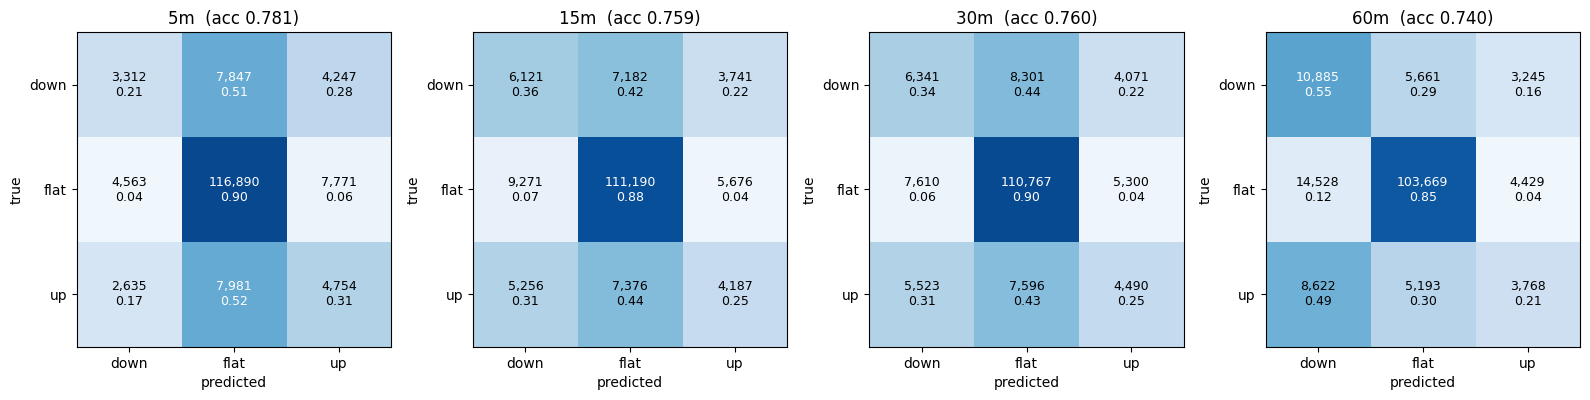

In [18]:
# Per-class metrics + confusion matrix per horizon
fig, axes = plt.subplots(1, len(CFG.horizons), figsize=(4 * len(CFG.horizons), 4))
if len(CFG.horizons) == 1:
    axes = [axes]

for ax, H in zip(axes, CFG.horizons):
    test = results[H]['test']
    cm = confusion_matrix(test['true'], test['pred'], labels=[0, 1, 2])
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['down', 'flat', 'up'])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['down', 'flat', 'up'])
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{H}m  (acc {test["acc"]:.3f})')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i,j]:,}\n{cm_norm[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=9)
    print(f'\n--- {H}m per-class metrics ---')
    print(per_class_metrics(test['true'], test['pred']).to_string(index=False))
plt.tight_layout(); plt.show()

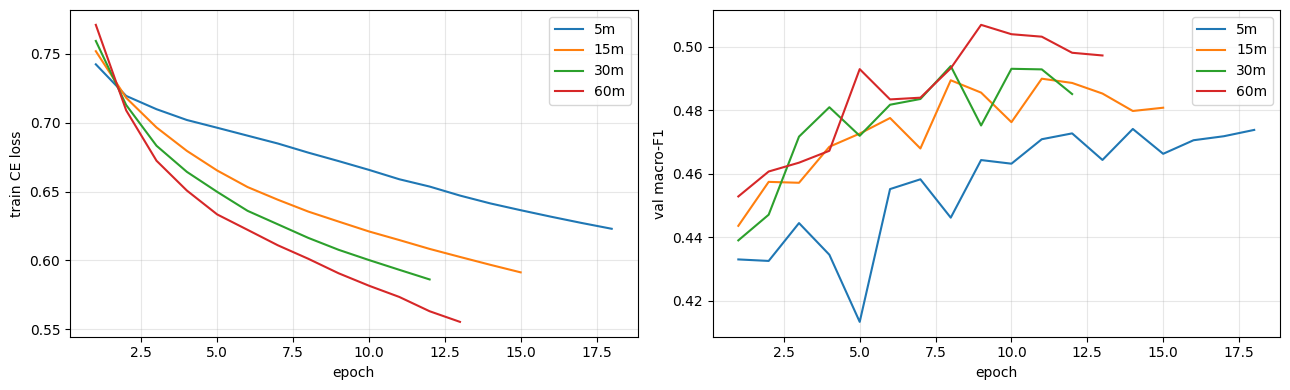

In [15]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for H in CFG.horizons:
    hist = pd.DataFrame(results[H]['history'])
    axes[0].plot(hist['epoch'], hist['train_loss'], label=f'{H}m')
    axes[1].plot(hist['epoch'], hist['val_macro_f1'], label=f'{H}m')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train CE loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1');  axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Confidence-vs-accuracy curve

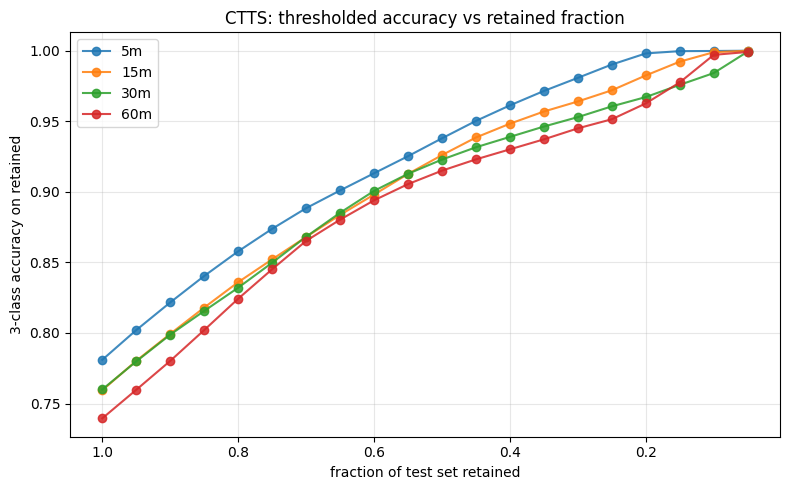

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for H in CFG.horizons:
    test = results[H]['test']
    conf = test['probs'].max(axis=1)
    pred = test['probs'].argmax(axis=1)
    correct = (pred == test['true']).astype(int)

    qs = np.linspace(0.0, 0.95, 20)
    accs, fracs = [], []
    for q in qs:
        thr  = np.quantile(conf, q)
        keep = conf >= thr
        if keep.sum() < 50:
            accs.append(np.nan); fracs.append(0.0); continue
        accs.append(correct[keep].mean())
        fracs.append(keep.mean())
    ax.plot(fracs, accs, marker='o', label=f'{H}m', alpha=0.85)
ax.set_xlabel('fraction of test set retained')
ax.set_ylabel('3-class accuracy on retained')
ax.set_title('CTTS: thresholded accuracy vs retained fraction')
ax.invert_xaxis()
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()